# Fit st and fpt with uncertainties in their slopes and breakpoint  
- Use 

In [20]:
import numpy as np
import pandas as pd
from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
from tes.algo_umap import UmapAlgo
from tes.algo_partial_full import AlgoParFull
from tes.commAnalysis import CommPercentages
from tes.DataUtils import DataUtils
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr, linregress 
from scipy.optimize import curve_fit
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from matplotlib import cm
from pathlib import Path
import os
import glob
import networkx as nx
import pwlf
import pickle
import umap

In [21]:
algo_umap = UmapAlgo()
algo= AlgoParFull()
analyse= AnalysisFunc()
reader = DataRead()
comm_ops = CommPercentages()
utils = DataUtils()

..\..\data\connectivity_matrix\mb_communities.npz already exists
DataUtils initialized


Piecewise linear fit define function 

In [3]:
data_folder = Path('../../data/results/calculate_final_params')
files=glob.glob(f"{data_folder}/final_*.pkl")
print(files)

['..\\..\\data\\results\\calculate_final_params\\final_bla.pkl', '..\\..\\data\\results\\calculate_final_params\\final_enti.pkl', '..\\..\\data\\results\\calculate_final_params\\final_fn.pkl', '..\\..\\data\\results\\calculate_final_params\\final_lha.pkl', '..\\..\\data\\results\\calculate_final_params\\final_lsc.pkl', '..\\..\\data\\results\\calculate_final_params\\final_mob.pkl', '..\\..\\data\\results\\calculate_final_params\\final_mop.pkl', '..\\..\\data\\results\\calculate_final_params\\final_mos.pkl', '..\\..\\data\\results\\calculate_final_params\\final_mrn.pkl', '..\\..\\data\\results\\calculate_final_params\\final_orb.pkl', '..\\..\\data\\results\\calculate_final_params\\final_peri.pkl', '..\\..\\data\\results\\calculate_final_params\\final_pir.pkl', '..\\..\\data\\results\\calculate_final_params\\final_re.pkl']


In [13]:
def fit_piecewiseLinear(data, ax, label):
    # intervals as this is the time when state changes from another state
    
    intervals = data.copy()
    # print(f'original values: {intervals}')
    intervals = np.sort(intervals)
    n = len(intervals)

    # CCDF: P(T > t)
    ccdf = 1.0 - np.arange(1, n + 1) / n

    # Remove zero values (log undefined)
    mask = ccdf > 0
    intervals = intervals[mask]
    ccdf = ccdf[mask]

    # Log of CCDF
    log_ccdf = np.log(ccdf)

    x = intervals
    y = log_ccdf

    # Fit piecewise linear model with 2 segments
    my_pwlf = pwlf.PiecewiseLinFit(x, y)
    res = my_pwlf.fit(2)

    # Breakpoints returned by pwlf.fit
    breakpoints = res   # e.g. [min_x, breakpoint, max_x]

    # First segment is between breakpoints[0] and breakpoints[1]
    # finding out interval values which contributed to slope 1
    mask_slope1 = (x >= breakpoints[0]) & (x <= breakpoints[1])
    entries_slope1 = x[mask_slope1]

    # print("Entries belonging to slope 1:", entries_slope1.tolist())
     # Entries corresponding to slope 2 (between res[1] and res[2])
    mask2 = (x >= res[1]) & (x <= res[2])
    entries_slope2 = x[mask2]

    # Predict
    y_hat = my_pwlf.predict(x)

    # Plot
    ax.scatter(x, y, label="Data")
    ax.plot(x, y_hat, 'r', label="Piecewise fit")
    ax.set_ylabel("log P(T > t)")
    ax.set_title(f"Log-CCDF breakpoint ~ {round(res[1])} {label}")
    ax.legend()

    # Slopes of the fitted lines
    slopes = my_pwlf.calc_slopes()
    se_betas=my_pwlf.standard_errors()
    

    print("Slopes of fitted lines:", slopes)
    print("SE for early slopes",se_betas[1])

    # Optionally annotate slopes on the plot
    for i, slope in enumerate(slopes):
        ax.text(x.mean(), y_hat.mean() - i*0.5, f"Slope {i+1}: {slope:.3f}", color="blue")

    return {'exp':slopes, 'joint': round(res[1]),'slope_1_entries':entries_slope1.tolist(),'s2':entries_slope2.tolist(),'s1_se':se_betas[1]}


For part fpt

Processing file: ..\..\data\results\calculate_final_params\final_bla.pkl
Slopes of fitted lines: [-0.0027969  -0.01671767]
SE for early slopes 0.00013333688900138722
Processing file: ..\..\data\results\calculate_final_params\final_enti.pkl
Slopes of fitted lines: [-0.00406935 -0.04090817]
SE for early slopes 7.654491970197502e-05
Processing file: ..\..\data\results\calculate_final_params\final_fn.pkl
Slopes of fitted lines: [-0.00428925 -0.0334581 ]
SE for early slopes 6.27307344071776e-05
Processing file: ..\..\data\results\calculate_final_params\final_lha.pkl
Slopes of fitted lines: [-0.00400745 -0.04825537]
SE for early slopes 0.00013386333616110816
Processing file: ..\..\data\results\calculate_final_params\final_lsc.pkl
Slopes of fitted lines: [-0.00473715 -0.05207831]
SE for early slopes 6.773143533036703e-05
Processing file: ..\..\data\results\calculate_final_params\final_mob.pkl
Slopes of fitted lines: [-0.00383098 -0.02368941]
SE for early slopes 7.896589684963015e-05
Processin

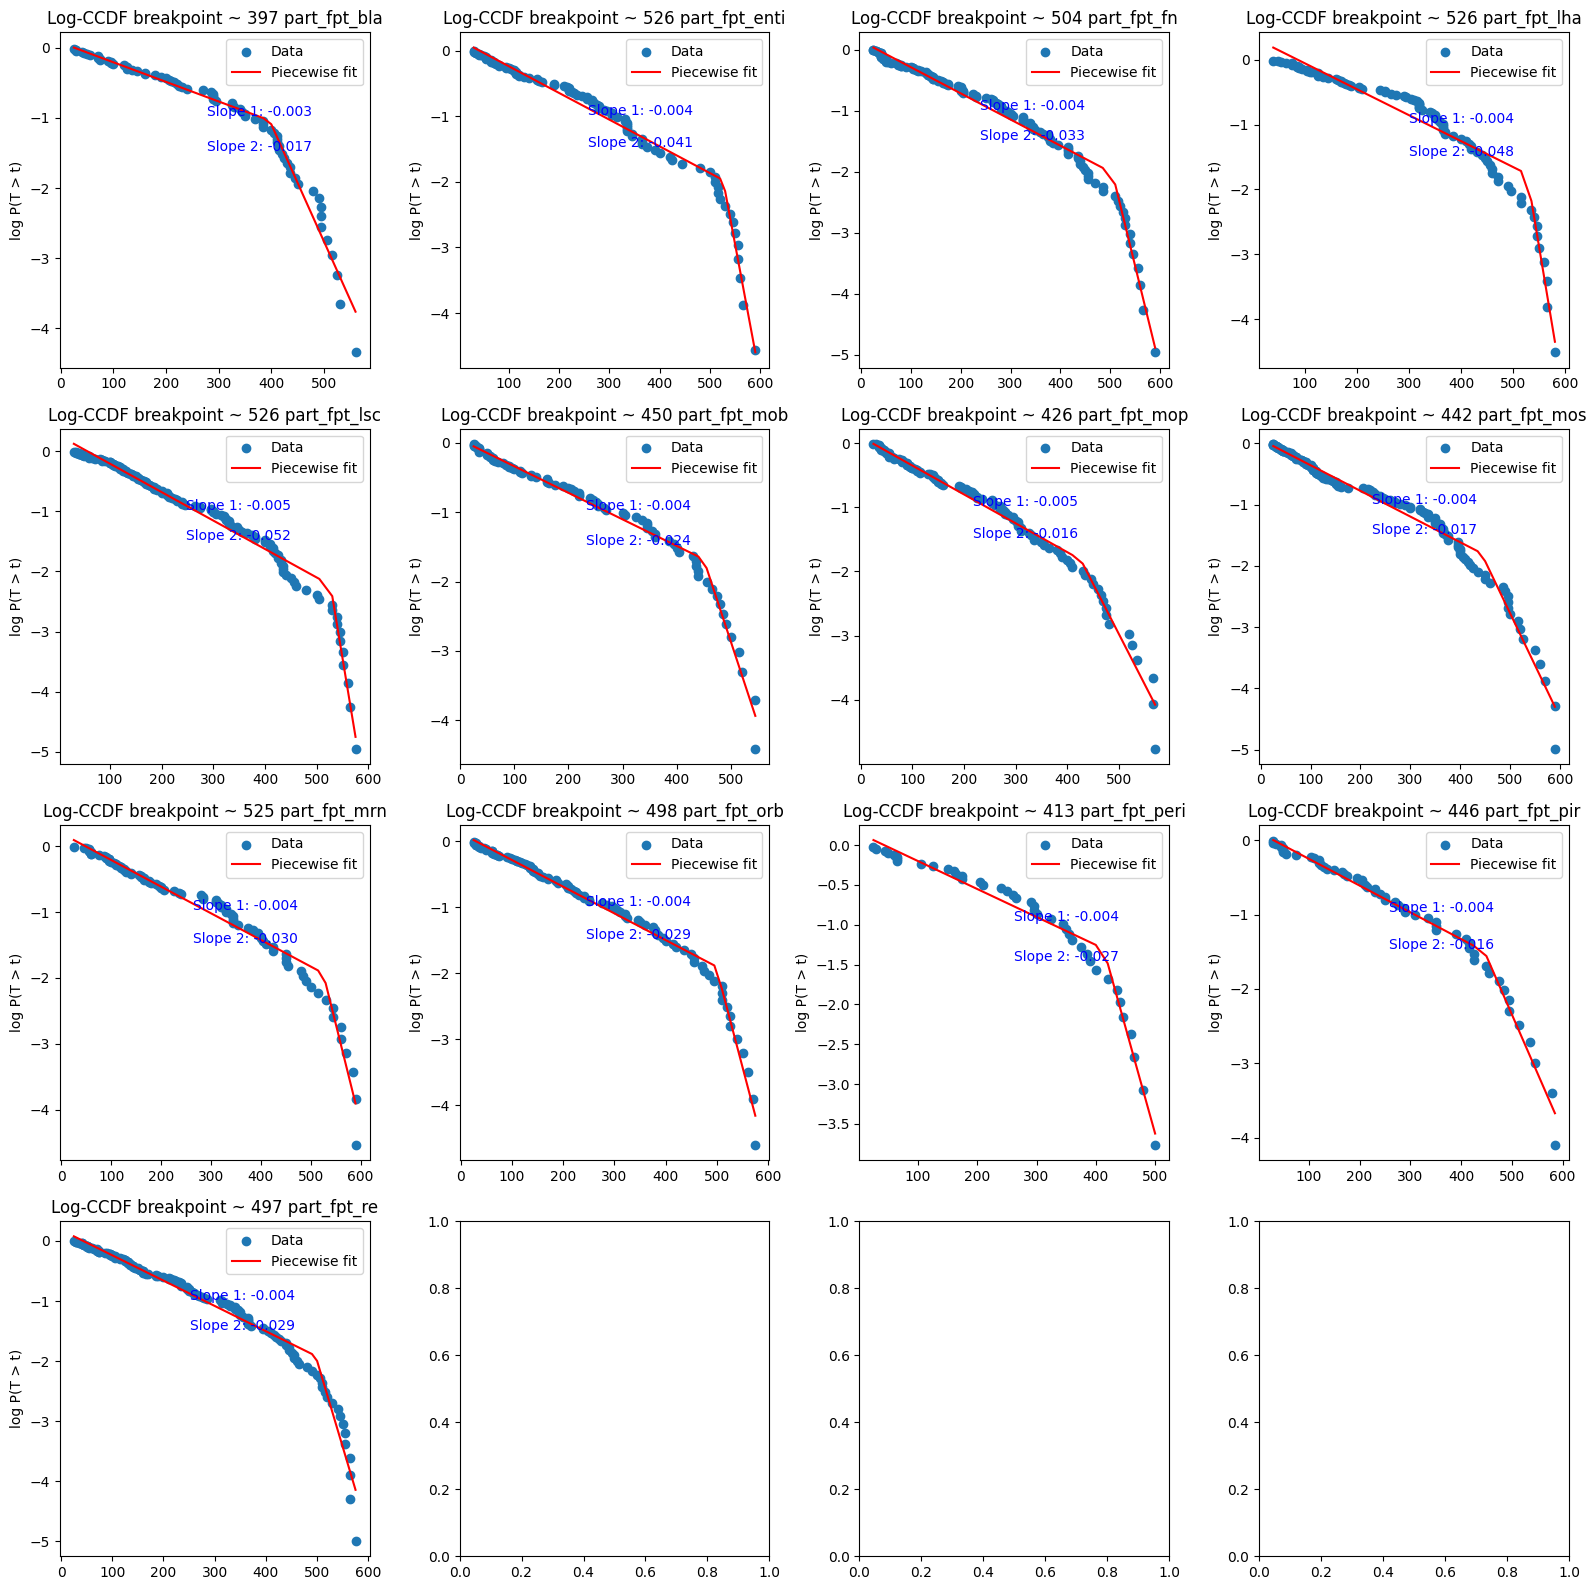

In [16]:
# Define grid size
nrows, ncols = 4, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 16))

# Flatten axes for easy iteration
axes = axes.flatten()

# initialize as dicts instead of lists
dict_exp1 = {}
dict_exp2 = {}
dict_joint = {}
dict_slp1_vals={}
# store standar error of early slopes
dict_slp1_se={}

for ax, file in zip(axes, files):
    print(f'Processing file: {file}')
   
    with open(file, "rb") as f:
        params = pickle.load(f)

    part_fpt = [x for x in params[1]["fp_t"] if 20 < x < 600]

    p = fit_piecewiseLinear(part_fpt, ax, f"part_fpt_{file.split('_')[-1].split('.')[-2]}")
    nw = file.split('_')[-1].split('.')[-2]

    # directly assign into dicts
    dict_exp1[nw] = p['exp'][0]
    dict_exp2[nw] = p['exp'][1]
    dict_joint[nw] = p['joint']
    dict_slp1_vals[nw]=p['slope_1_entries']
    dict_slp1_se[nw]=p['s1_se']

    

plt.tight_layout()
# plt.savefig('../../data/results/Part_FPT_fit.png', format='png')
plt.show()


In [17]:
dict_slp1_se

{'bla': 0.00013333688900138722,
 'enti': 7.654491970197502e-05,
 'fn': 6.27307344071776e-05,
 'lha': 0.00013386333616110816,
 'lsc': 6.773143533036703e-05,
 'mob': 7.896589684963015e-05,
 'mop': 8.26759787104747e-05,
 'mos': 7.911890178545498e-05,
 'mrn': 9.960984202194108e-05,
 'orb': 5.992592138328281e-05,
 'peri': 0.00015528715720235171,
 'pir': 9.548073859279774e-05,
 're': 8.168054151536047e-05}

Applying T test comparing every with FN

In [22]:
def compare_slopes(m1, se1, m2, se2):
    """
    Returns the t-statistic and p-value for the comparison of two slopes.
    """
    
    # Calculate the t-statistic
    t_stat = (m1 - m2) / np.sqrt(se1**2 + se2**2)
    
    # Calculate p-value (two-tailed)
    # Using normal distribution (Z-test) as a standard approximation for large N
    p_value = 2 * (1 - stats.norm.cdf(abs(t_stat)))
    
    return t_stat, p_value






In [26]:
for s,se in zip(list(dict_exp1.values()),list(dict_slp1_se.values())):
    t, p = compare_slopes(dict_exp1['fn'], dict_slp1_se['fn'],s,se)
    print(f"T-statistic: {t:.4f}, P-value: {p:.4f}")

T-statistic: -10.1275, P-value: 0.0000
T-statistic: -2.2219, P-value: 0.0263
T-statistic: 0.0000, P-value: 1.0000
T-statistic: -1.9062, P-value: 0.0566
T-statistic: 4.8518, P-value: 0.0000
T-statistic: -4.5441, P-value: 0.0000
T-statistic: 2.0987, P-value: 0.0358
T-statistic: -0.9983, P-value: 0.3181
T-statistic: -2.1183, P-value: 0.0342
T-statistic: -2.8708, P-value: 0.0041
T-statistic: -4.6623, P-value: 0.0000
T-statistic: -6.0678, P-value: 0.0000
T-statistic: -0.7194, P-value: 0.4719


### FPT full

Processing file: ..\..\data\results\calculate_final_params\final_bla.pkl
Slopes of fitted lines: [-0.00172848 -0.01562145]
SE for early slopes 0.0006713497625712931
Processing file: ..\..\data\results\calculate_final_params\final_enti.pkl
Slopes of fitted lines: [-0.0024804  -0.01186928]
SE for early slopes 0.00020444566028783156
Processing file: ..\..\data\results\calculate_final_params\final_fn.pkl
Slopes of fitted lines: [-0.00348524 -0.0238253 ]
SE for early slopes 0.00015133147201320702
Processing file: ..\..\data\results\calculate_final_params\final_lha.pkl
Slopes of fitted lines: [-0.00202077 -0.01664001]
SE for early slopes 0.00034301600823097544
Processing file: ..\..\data\results\calculate_final_params\final_lsc.pkl
Slopes of fitted lines: [-0.00243672 -0.01660122]
SE for early slopes 0.0002320868335311135
Processing file: ..\..\data\results\calculate_final_params\final_mob.pkl
Slopes of fitted lines: [-0.00225862 -0.0156471 ]
SE for early slopes 0.0001836566520535275
Process

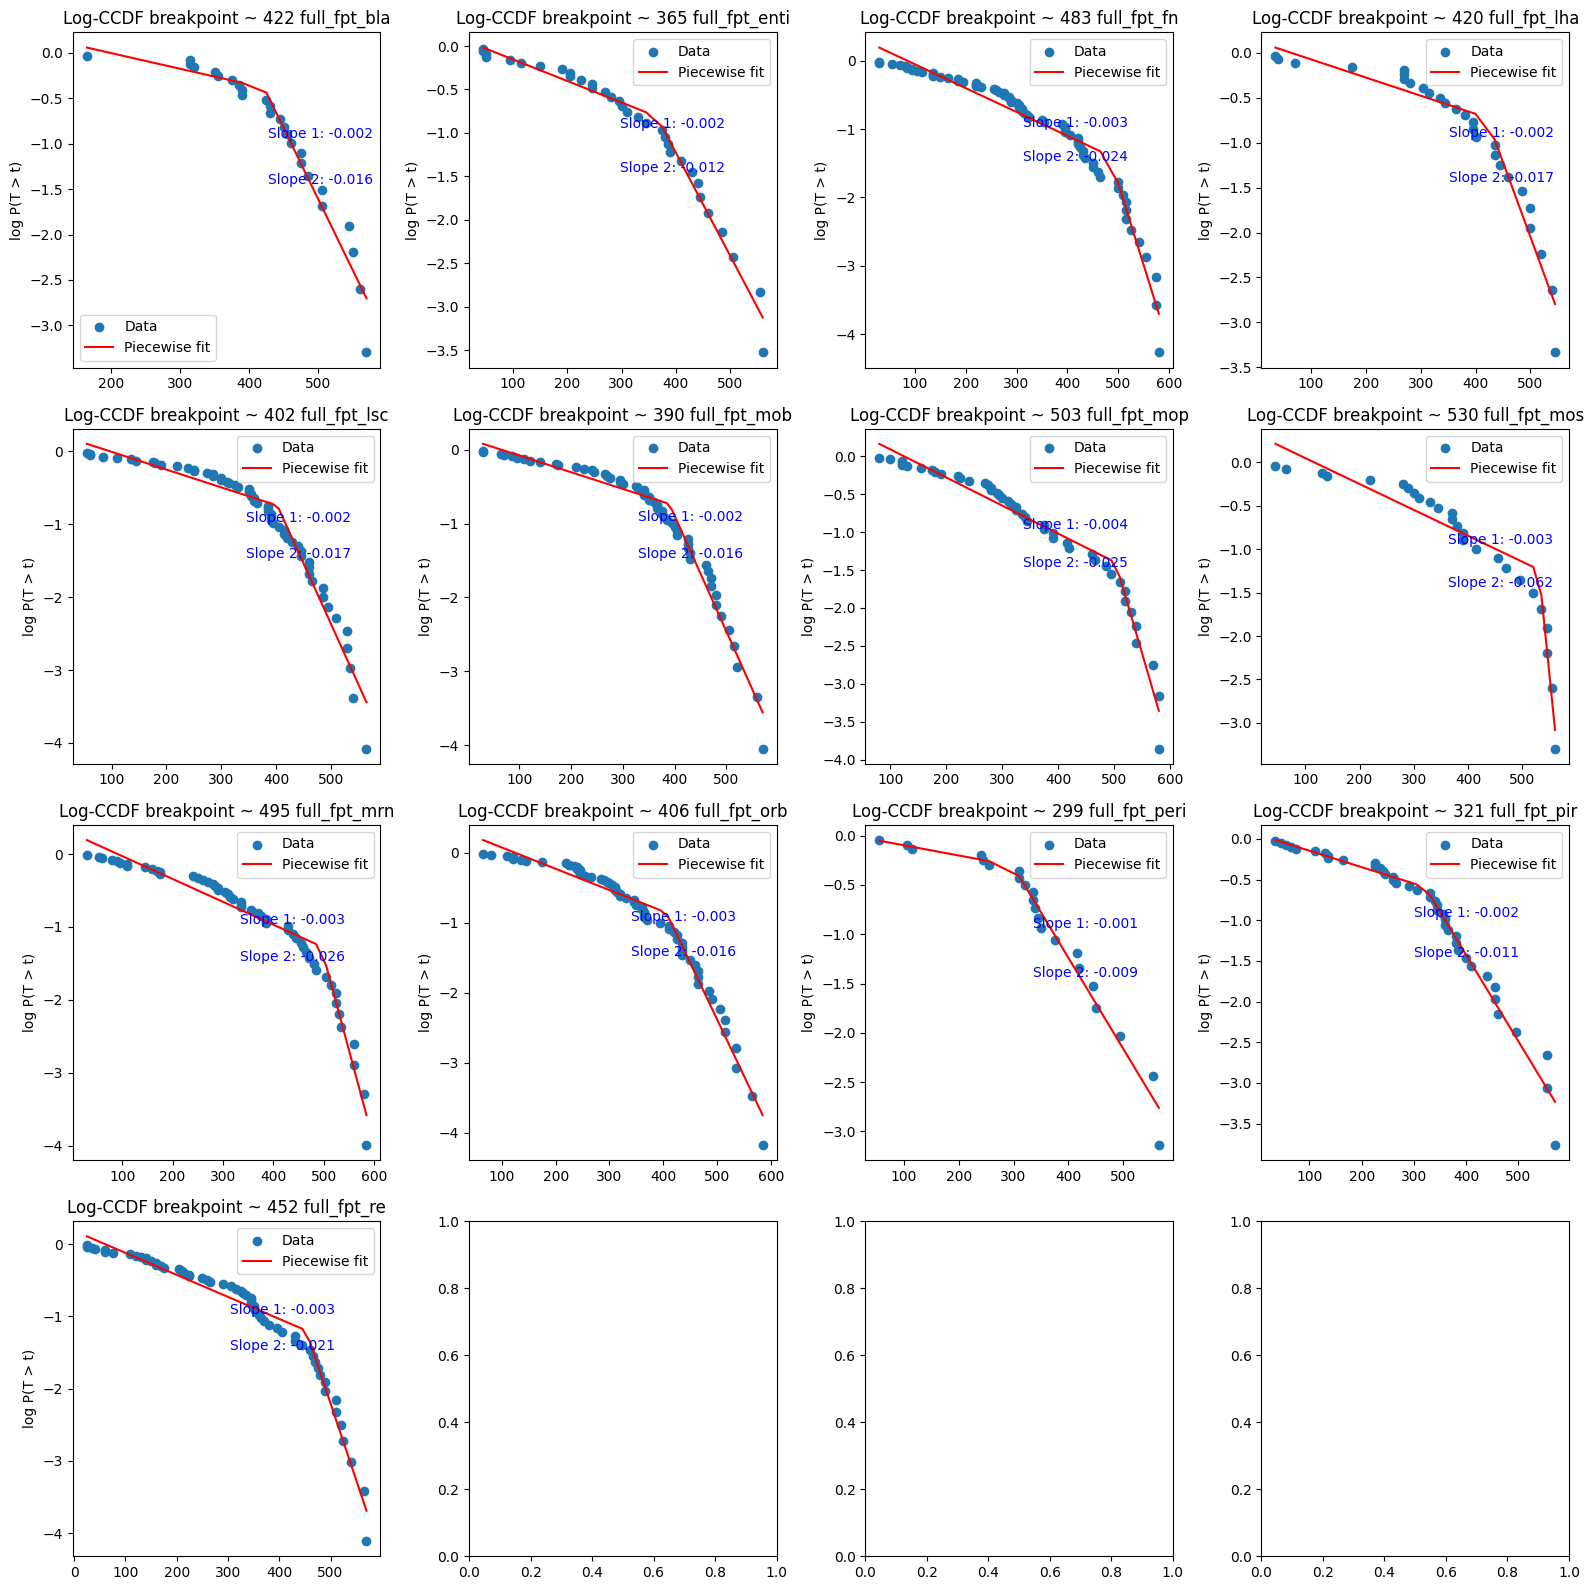

In [30]:
# Define grid size
nrows, ncols = 4, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 16))

# Flatten axes for easy iteration
axes = axes.flatten()

# initialize as dicts instead of lists
dict_exp1 = {}
dict_exp2 = {}
dict_joint = {}
dict_slp1_vals={}
# store standar error of early slopes
dict_slp1_se={}

for ax, file in zip(axes, files):
    print(f'Processing file: {file}')
   
    with open(file, "rb") as f:
        params = pickle.load(f)

    full_fpt = [x for x in params[2]["fp_t"] if 20 < x < 600]

    p = fit_piecewiseLinear(full_fpt, ax, f"full_fpt_{file.split('_')[-1].split('.')[-2]}")
    nw = file.split('_')[-1].split('.')[-2]

    # directly assign into dicts
    dict_exp1[nw] = p['exp'][0]
    dict_exp2[nw] = p['exp'][1]
    dict_joint[nw] = p['joint']
    dict_slp1_vals[nw]=p['slope_1_entries']
    dict_slp1_se[nw]=p['s1_se']

    

plt.tight_layout()
# plt.savefig('../../data/results/Part_FPT_fit.png', format='png')
plt.show()


t test

In [29]:
for s,se in zip(list(dict_exp1.values()),list(dict_slp1_se.values())):
    t, p = compare_slopes(dict_exp1['fn'], dict_slp1_se['fn'],s,se)
    print(f"T-statistic: {t:.4f}, P-value: {p:.4f}")

T-statistic: -2.5513, P-value: 0.0107
T-statistic: -3.9475, P-value: 0.0001
T-statistic: 0.0000, P-value: 1.0000
T-statistic: -3.9073, P-value: 0.0001
T-statistic: -3.7847, P-value: 0.0002
T-statistic: -5.1532, P-value: 0.0000
T-statistic: 0.8878, P-value: 0.3746
T-statistic: -1.5432, P-value: 0.1228
T-statistic: -1.5727, P-value: 0.1158
T-statistic: -1.8267, P-value: 0.0677
T-statistic: -5.4144, P-value: 0.0000
T-statistic: -5.3105, P-value: 0.0000
T-statistic: -2.1687, P-value: 0.0301


### Part ST

Processing file: ..\..\data\results\calculate_final_params\final_bla.pkl
Slopes of fitted lines: [-0.01861496 -0.00376382]
SE for early slopes 0.00018442116173481357
Processing file: ..\..\data\results\calculate_final_params\final_enti.pkl
Slopes of fitted lines: [-0.02865546 -0.00808019]
SE for early slopes 0.00045209675555370486
Processing file: ..\..\data\results\calculate_final_params\final_fn.pkl
Slopes of fitted lines: [-0.02424336 -0.01373923]
SE for early slopes 0.0002522150596048858
Processing file: ..\..\data\results\calculate_final_params\final_lha.pkl
Slopes of fitted lines: [-0.0324479  -0.00793583]
SE for early slopes 0.0005533271969952687
Processing file: ..\..\data\results\calculate_final_params\final_lsc.pkl
Slopes of fitted lines: [-0.02284351 -0.0079143 ]
SE for early slopes 0.0003979102571768912
Processing file: ..\..\data\results\calculate_final_params\final_mob.pkl
Slopes of fitted lines: [-0.02858204 -0.00603464]
SE for early slopes 0.0004357400901477834
Processi

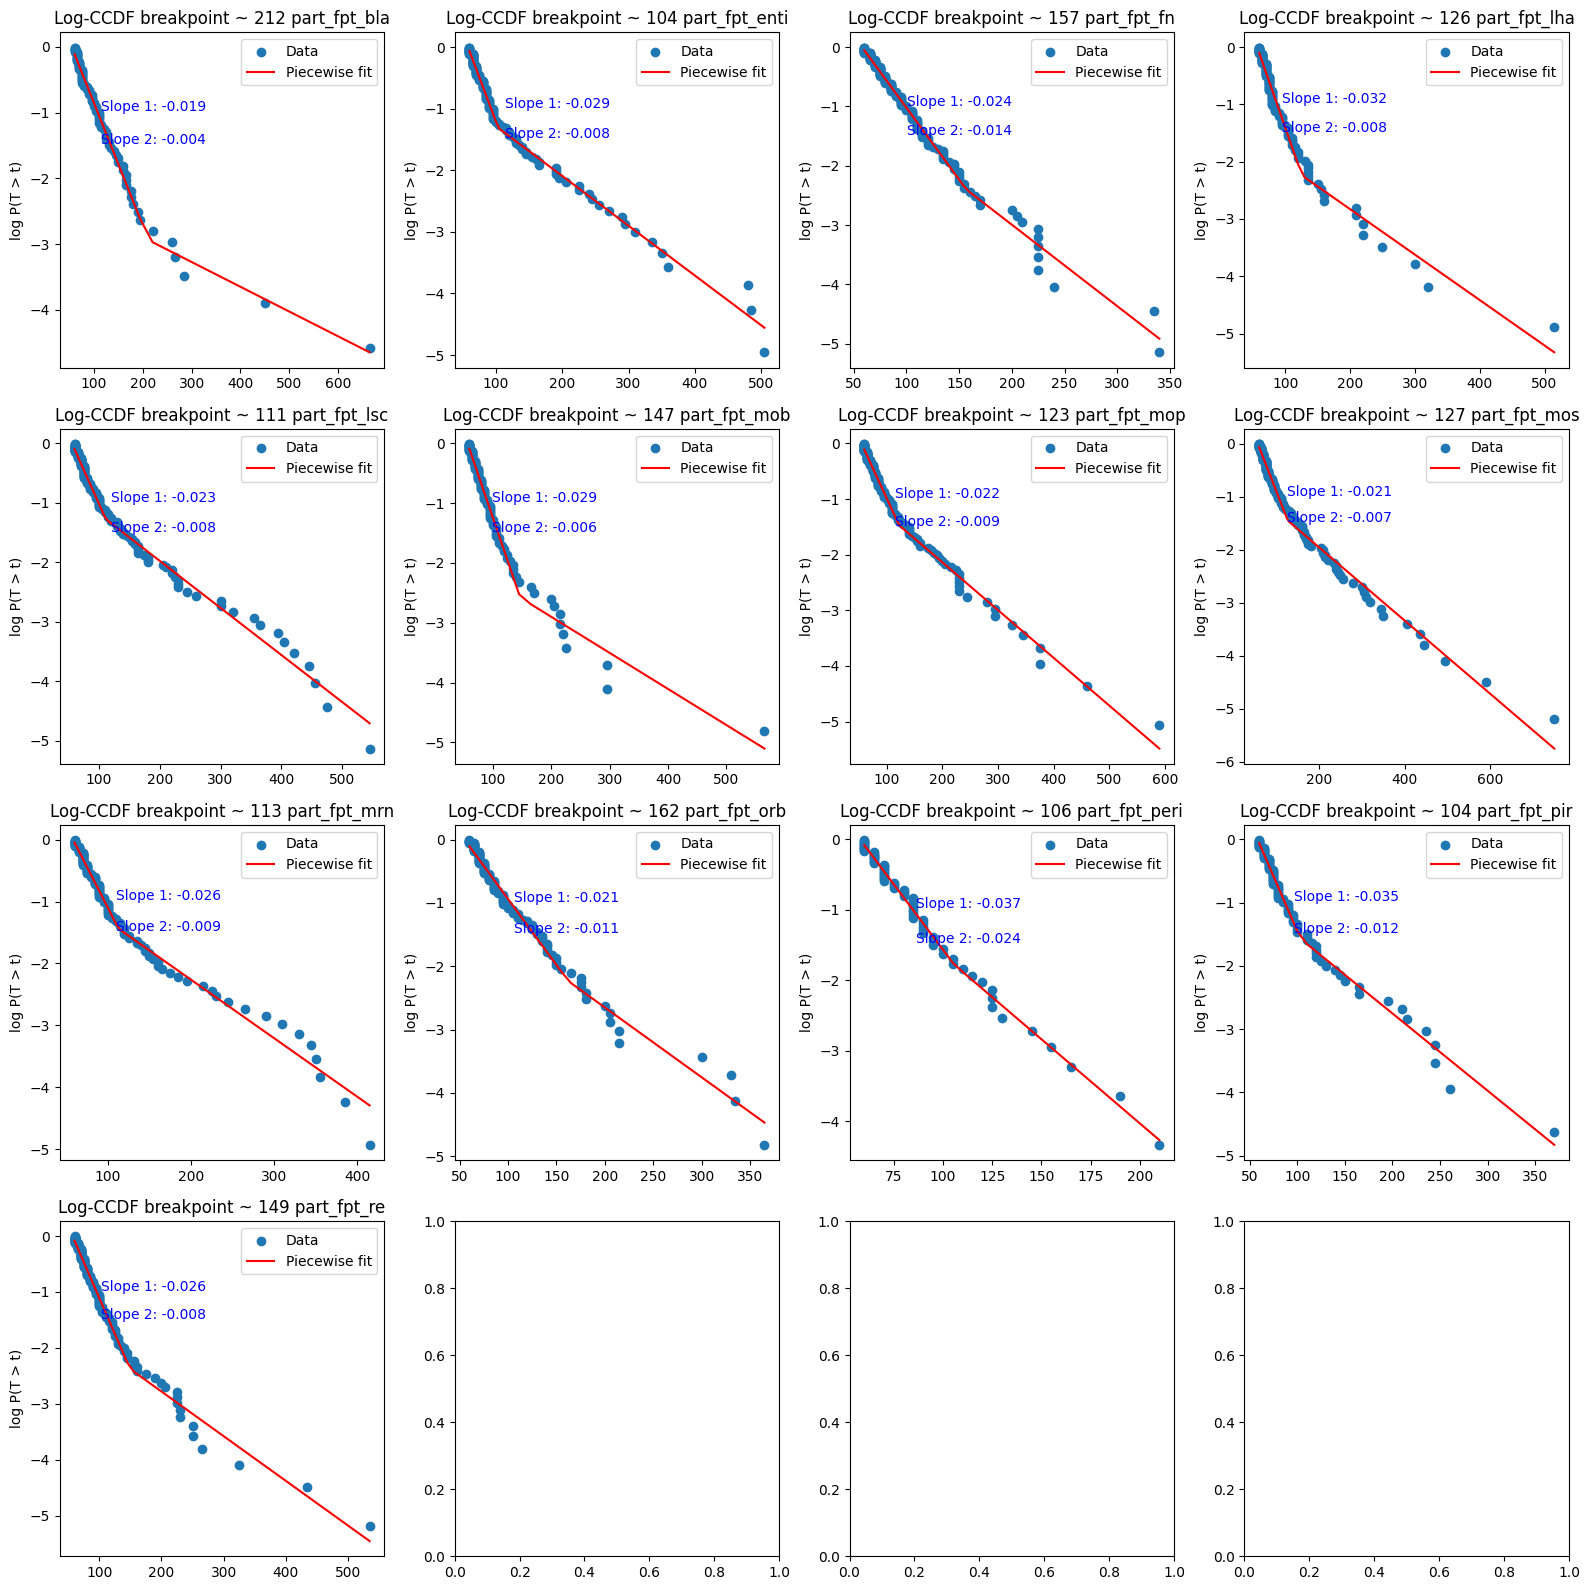

In [31]:
# Define grid size
nrows, ncols = 4, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 16))

# Flatten axes for easy iteration
axes = axes.flatten()

# initialize as dicts instead of lists
dict_exp1 = {}
dict_exp2 = {}
dict_joint = {}
dict_slp1_vals={}
# store standar error of early slopes
dict_slp1_se={}

for ax, file in zip(axes, files):
    print(f'Processing file: {file}')
   
    with open(file, "rb") as f:
        params = pickle.load(f)

    part_st = [x for x in params[1]["s_t"] if 25 < x < 800]

    p = fit_piecewiseLinear(part_st, ax, f"part_fpt_{file.split('_')[-1].split('.')[-2]}")
    nw = file.split('_')[-1].split('.')[-2]

    # directly assign into dicts
    dict_exp1[nw] = p['exp'][0]
    dict_exp2[nw] = p['exp'][1]
    dict_joint[nw] = p['joint']
    dict_slp1_vals[nw]=p['slope_1_entries']
    dict_slp1_se[nw]=p['s1_se']

    

plt.tight_layout()
# plt.savefig('../../data/results/Part_FPT_fit.png', format='png')
plt.show()


T test on early slope part st

In [32]:
for s,se in zip(list(dict_exp1.values()),list(dict_slp1_se.values())):
    t, p = compare_slopes(dict_exp1['fn'], dict_slp1_se['fn'],s,se)
    print(f"T-statistic: {t:.4f}, P-value: {p:.4f}")

T-statistic: -18.0139, P-value: 0.0000
T-statistic: 8.5226, P-value: 0.0000
T-statistic: 0.0000, P-value: 1.0000
T-statistic: 13.4921, P-value: 0.0000
T-statistic: -2.9714, P-value: 0.0030
T-statistic: 8.6176, P-value: 0.0000
T-statistic: -6.5326, P-value: 0.0000
T-statistic: -8.8829, P-value: 0.0000
T-statistic: 3.5581, P-value: 0.0004
T-statistic: -8.1618, P-value: 0.0000
T-statistic: 19.1711, P-value: 0.0000
T-statistic: 14.9953, P-value: 0.0000
T-statistic: 3.7205, P-value: 0.0002
